# APISR GRL 4× 推理 (Inference)

本 Notebook 集成 [APISR](https://github.com/Kiteretsu77/APISR) 的 **GRL**（Global-Regional-Local）预训练模型，对低分辨率图像做 **4× 超分**。GRL 为论文默认架构之一，仅支持 4×。

- **权重**：从 APISR Model Zoo 下载 `4x_APISR_GRL_GAN_generator.pth` 放入 `pretrained_models/`
- **输入**：`dataset/lowres_4x/original`
- **输出**：`results/APISR_GRL_4x_inference`

In [2]:
import os
import sys
import glob
import random
import cv2
import numpy as np
import matplotlib.pyplot as plt
import torch
from torchvision.transforms import ToTensor

apisr_tools_path = os.path.abspath('APISR_tools')
if apisr_tools_path not in sys.path:
    sys.path.insert(0, apisr_tools_path)
from architecture.grl import GRL

print('PyTorch:', torch.__version__)
print('CUDA:', torch.cuda.is_available())

/home/shunyu/miniconda3/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


PyTorch: 2.10.0+cu128
CUDA: True


/home/shunyu/miniconda3/lib/python3.12/site-packages/timm/models/layers/__init__.py:49: FutureWarning: Importing from timm.models.layers is deprecated, please import via timm.layers
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.layers", FutureWarning)


In [3]:
SCALE = 4
MODEL_PATH = 'pretrained_models/4x_APISR_GRL_GAN_generator.pth'
LR_DIR = 'dataset/lowres_4x/original'
HR_DIR = 'dataset/highres/original'
OUTPUT_DIR = 'results/APISR_GRL_4x_inference'
TILE = 256
TILE_PAD = 16

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Device:', device)
print('Model:', MODEL_PATH)

Device: cuda
Model: pretrained_models/4x_APISR_GRL_GAN_generator.pth


In [4]:
# GRL tiny2 (与 APISR test_utils.load_grl 一致)
generator = GRL(
    upscale=SCALE,
    img_size=64,
    window_size=8,
    depths=[4, 4, 4, 4],
    embed_dim=64,
    num_heads_window=[2, 2, 2, 2],
    num_heads_stripe=[2, 2, 2, 2],
    mlp_ratio=2,
    qkv_proj_type='linear',
    anchor_proj_type='avgpool',
    anchor_window_down_factor=2,
    out_proj_type='linear',
    conv_type='1conv',
    upsampler='nearest+conv',
).to(device)

if not os.path.exists(MODEL_PATH):
    raise FileNotFoundError(f'未找到权重: {MODEL_PATH}\n请从 APISR Model Zoo 下载 4x_APISR_GRL_GAN_generator.pth')

ckpt = torch.load(MODEL_PATH, map_location=device, weights_only=False)
if 'model_state_dict' not in ckpt:
    raise KeyError('Checkpoint 需包含 model_state_dict')
weight = ckpt['model_state_dict'].copy()
for old_key in list(weight.keys()):
    if old_key.startswith('_orig_mod.'):
        weight[old_key[10:]] = weight.pop(old_key)
generator.load_state_dict(weight, strict=True)
generator.eval()
print('GRL 模型加载完成。')

GRL 模型加载完成。


In [5]:
def infer_one(lr_path, save_dir=None, tile=0, tile_pad=16):
    img = cv2.imread(lr_path, cv2.IMREAD_COLOR)
    if img is None:
        return None
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    h, w = img.shape[:2]
    if h % 4 != 0:
        img = img[:4*(h//4), :, :]
    if w % 4 != 0:
        img = img[:, :4*(w//4), :]
    h, w = img.shape[:2]
    x = ToTensor()(img).unsqueeze(0).to(device)

    if tile > 0 and (h > tile or w > tile):
        out = torch.zeros(1, 3, h * SCALE, w * SCALE, device='cpu', dtype=torch.float32)
        weight = torch.zeros(1, 1, h * SCALE, w * SCALE, device='cpu', dtype=torch.float32)
        for y in range(0, h, tile):
            for x0 in range(0, w, tile):
                y1, x1 = min(y + tile, h), min(x0 + tile, w)
                y0p = max(y - tile_pad, 0)
                x0p = max(x0 - tile_pad, 0)
                y1p = min(y1 + tile_pad, h)
                x1p = min(x1 + tile_pad, w)
                patch = x[:, :, y0p:y1p, x0p:x1p].to(device)
                with torch.no_grad():
                    pred = generator(patch).float().cpu()
                th, tw = (y1 - y) * SCALE, (x1 - x0) * SCALE
                oy, ox = y * SCALE, x0 * SCALE
                out[:, :, oy:oy+th, ox:ox+tw] += pred[:, :, (y-y0p)*SCALE:(y1-y0p)*SCALE, (x0-x0p)*SCALE:(x1-x0p)*SCALE]
                weight[:, :, oy:oy+th, ox:ox+tw] += 1.0
        sr = (out / weight.clamp(min=1e-6)).clamp(0, 1)
    else:
        with torch.no_grad():
            sr = generator(x).float().cpu().clamp(0, 1)

    sr_np = (sr.squeeze(0).permute(1, 2, 0).numpy() * 255).round().astype(np.uint8)
    sr_bgr = cv2.cvtColor(sr_np, cv2.COLOR_RGB2BGR)
    if save_dir:
        os.makedirs(save_dir, exist_ok=True)
        base = os.path.splitext(os.path.basename(lr_path))[0]
        cv2.imwrite(os.path.join(save_dir, f'{base}.png'), sr_bgr)
    return sr_bgr

APISR GRL 4x:  51%|█████     | 221/434 [04:00<02:31,  1.41it/s]

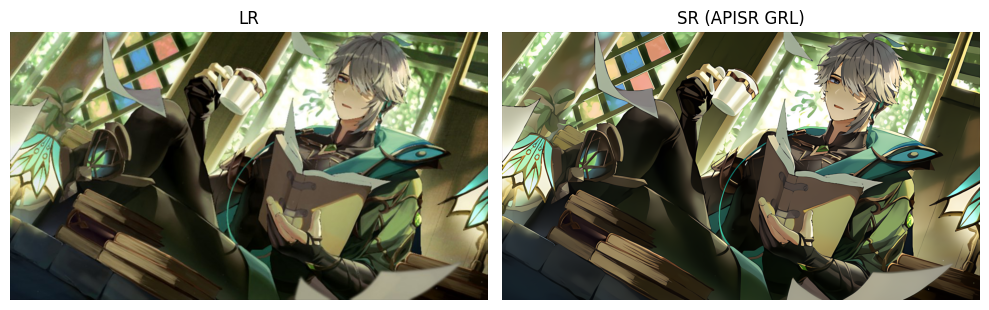

APISR GRL 4x:  84%|████████▍ | 365/434 [06:26<00:46,  1.49it/s]

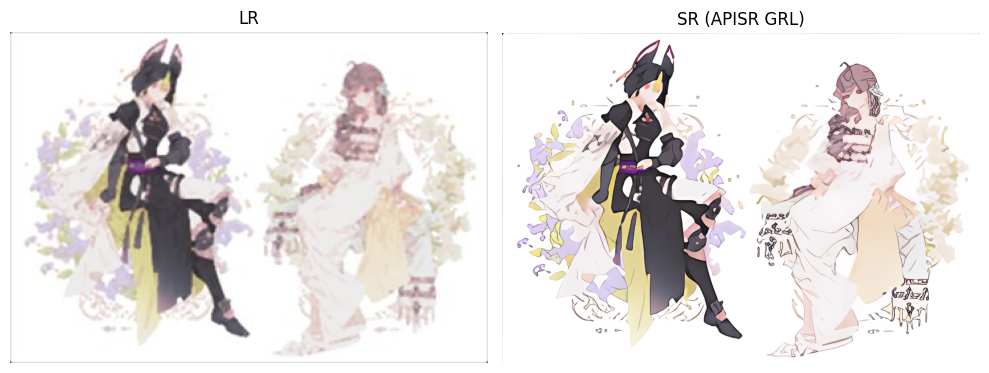

APISR GRL 4x:  89%|████████▉ | 387/434 [06:49<00:42,  1.11it/s]

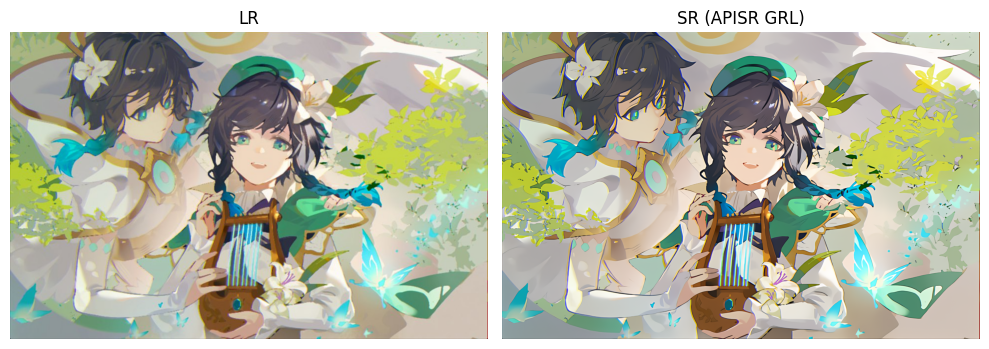

APISR GRL 4x: 100%|██████████| 434/434 [07:34<00:00,  1.05s/it]

批量推理完成。


In [6]:
from tqdm import tqdm
lr_paths = sorted(glob.glob(os.path.join(LR_DIR, '*.*')))
if not lr_paths:
    raise FileNotFoundError(f'未找到 LR 图像: {LR_DIR}')
num_vis = min(3, len(lr_paths))
vis_idx = set(random.sample(range(len(lr_paths)), num_vis))
for i, p in enumerate(tqdm(lr_paths, desc='APISR GRL 4x')):
    out = infer_one(p, save_dir=OUTPUT_DIR, tile=TILE, tile_pad=TILE_PAD)
    if out is not None and i in vis_idx:
        lr = cv2.imread(p)
        lr = cv2.cvtColor(lr, cv2.COLOR_BGR2RGB)
        fig, ax = plt.subplots(1, 2, figsize=(10, 5))
        ax[0].imshow(lr); ax[0].set_title('LR'); ax[0].axis('off')
        ax[1].imshow(cv2.cvtColor(out, cv2.COLOR_BGR2RGB)); ax[1].set_title('SR (APISR GRL)'); ax[1].axis('off')
        plt.tight_layout(); plt.show()
print('批量推理完成。')

In [8]:
# 可选：NIQE / MANIQA / CLIPIQA
try:
    import pyiqa
except ImportError:
    print('未安装 pyiqa，跳过评估。')
else:
    sr_list = sorted(glob.glob(os.path.join(OUTPUT_DIR, '*.*')))
    if sr_list:
        dev = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
        niqe_m = pyiqa.create_metric('niqe', device=dev)
        maniqa_m = pyiqa.create_metric('maniqa', device=dev)
        clipiqa_m = pyiqa.create_metric('clipiqa', device=dev)
        n = [niqe_m(p).item() for p in tqdm(sr_list, desc='NIQE')]
        ma = [maniqa_m(p).item() for p in tqdm(sr_list, desc='MANIQA')]
        c = [clipiqa_m(p).item() for p in tqdm(sr_list, desc='CLIPIQA')]
        summary = f'APISR GRL — NIQE(↓): {np.mean(n):.4f}  MANIQA(↑): {np.mean(ma):.4f}  CLIPIQA(↑): {np.mean(c):.4f}'
        print(summary)
        with open(os.path.join(OUTPUT_DIR, 'scores.txt'), 'w') as f:
            f.write(summary + '\n')
        print('(Summary also saved to', os.path.join(OUTPUT_DIR, 'scores.txt') + ')')

Loading pretrained model MANIQA from /home/shunyu/.cache/torch/hub/pyiqa/ckpt_koniq10k.pt


CLIPIQA: 100%|██████████| 434/434 [07:44<00:00,  1.07s/it]

APISR GRL — NIQE(↓): 5.7950  MANIQA(↑): 0.4815  CLIPIQA(↑): 0.6766
(Summary also saved to results/APISR_GRL_4x_inference/scores.txt)
